## Best Optimization CV - Employer Bee Algo 2 + Onlooker Bee Algo 3

In [1]:
from Pipeline.Algorithm.ArtificialBeeColonyElmCV import ArtificialBeeColonyElmCV
from Pipeline.Algorithm.ArtificialBeeColonyElmCVEnsemble import ArtificialBeeColonyElmCVEnsemble
from Pipeline.Global.GallstoneDataSet import GallstoneDataSet
from Pipeline.Global.GlobalSetting import GlobalSetting
from Pipeline.Global.Plotting import Plotting
from Pipeline.Methodology.ABC_Testing import abc_testing

In [2]:
fold_id = 0
mod = f"Grid_Optimization_Fold_{fold_id}"

gallstone_dataset = GallstoneDataSet()
gallstone_dataset.fetch_data_path_1()
gallstone_dataset.cross_validate_test(5)

x_train, y_train, x_test, y_test = gallstone_dataset.fold_split[fold_id]

features_size = x_train.shape[1]

In [3]:
best_lambda_config = GlobalSetting.get_config_by_type("Grid_Optimization")
best_lambda_hidden_size = best_lambda_config["Hidden_Nodes"] if best_lambda_config else None
best_lambda_lambda_value = best_lambda_config["Lambda_Value"] if best_lambda_config else None

In [4]:
abc_r_elm_cv  = ArtificialBeeColonyElmCVEnsemble(
    features_size       = features_size,
    hidden_size         = best_lambda_hidden_size,
    activation_function = GlobalSetting.sigmoid             ,
    regularization_lambda=best_lambda_lambda_value           ,
    fitness_function    = GlobalSetting.evaluation_function ,
    solution_size       = GlobalSetting.solution_size       ,
    trial_limit         = GlobalSetting.trial_limit         ,
    max_iteration       = GlobalSetting.max_iteration
)
abc_r_elm_cv.employed_bee_apply_algo3()
abc_r_elm_cv.onlooker_bee_apply_algo2()

In [5]:
results_df , convergence_df , scout_df = abc_testing(abc_r_elm_cv, x_train, y_train, x_test, y_test)
results_df.describe()


Running simulation for Seed: 161...
Iteration 003 complete | Duration: 0.0658s | Scout Triggers: 4 | Best Fitness: 0.736885

Running simulation for Seed: 162...
Iteration 003 complete | Duration: 0.0529s | Scout Triggers: 2 | Best Fitness: 0.742042

Running simulation for Seed: 163...
Iteration 003 complete | Duration: 0.0387s | Scout Triggers: 4 | Best Fitness: 0.735123

Running simulation for Seed: 164...
Iteration 003 complete | Duration: 0.0493s | Scout Triggers: 4 | Best Fitness: 0.737899

Running simulation for Seed: 165...
Iteration 003 complete | Duration: 0.0512s | Scout Triggers: 3 | Best Fitness: 0.741879

Running simulation for Seed: 166...
Iteration 003 complete | Duration: 0.0805s | Scout Triggers: 4 | Best Fitness: 0.762036

Running simulation for Seed: 167...
Iteration 003 complete | Duration: 0.0722s | Scout Triggers: 3 | Best Fitness: 0.726797

Running simulation for Seed: 168...
Iteration 003 complete | Duration: 0.0602s | Scout Triggers: 2 | Best Fitness: 0.762870


,Accuracy,Precision,Recall,NPV,Specificity,F1-Score,F2-Score,Bal Accuracy,MCC,ABC_Seed
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.739583,0.791947,0.629032,0.708285,0.843434,0.700061,0.655456,0.736233,0.486093,175.500000
std,0.029399,0.042274,0.046976,0.027274,0.038234,0.037099,0.042801,0.029581,0.060008,8.803408
min,0.671875,0.720000,0.516129,0.642857,0.787879,0.603774,0.547945,0.667155,0.351765,161.000000
25%,0.718750,0.760000,0.588710,0.690934,0.818182,0.678571,0.623851,0.715543,0.442917,168.250000
50%,0.734375,0.795833,0.645161,0.705010,0.848485,0.697031,0.662252,0.731672,0.473883,175.500000
75%,0.765625,0.817340,0.669355,0.730030,0.878788,0.734450,0.688160,0.762708,0.535138,182.750000
max,0.781250,0.869565,0.709677,0.756757,0.909091,0.758621,0.728477,0.779081,0.577284,190.000000


[I/O Trace] Figure exported successfully: ../../Storage/Figure\ABC_Telemetry_Grid_Optimization_Fold_0_MCC.png


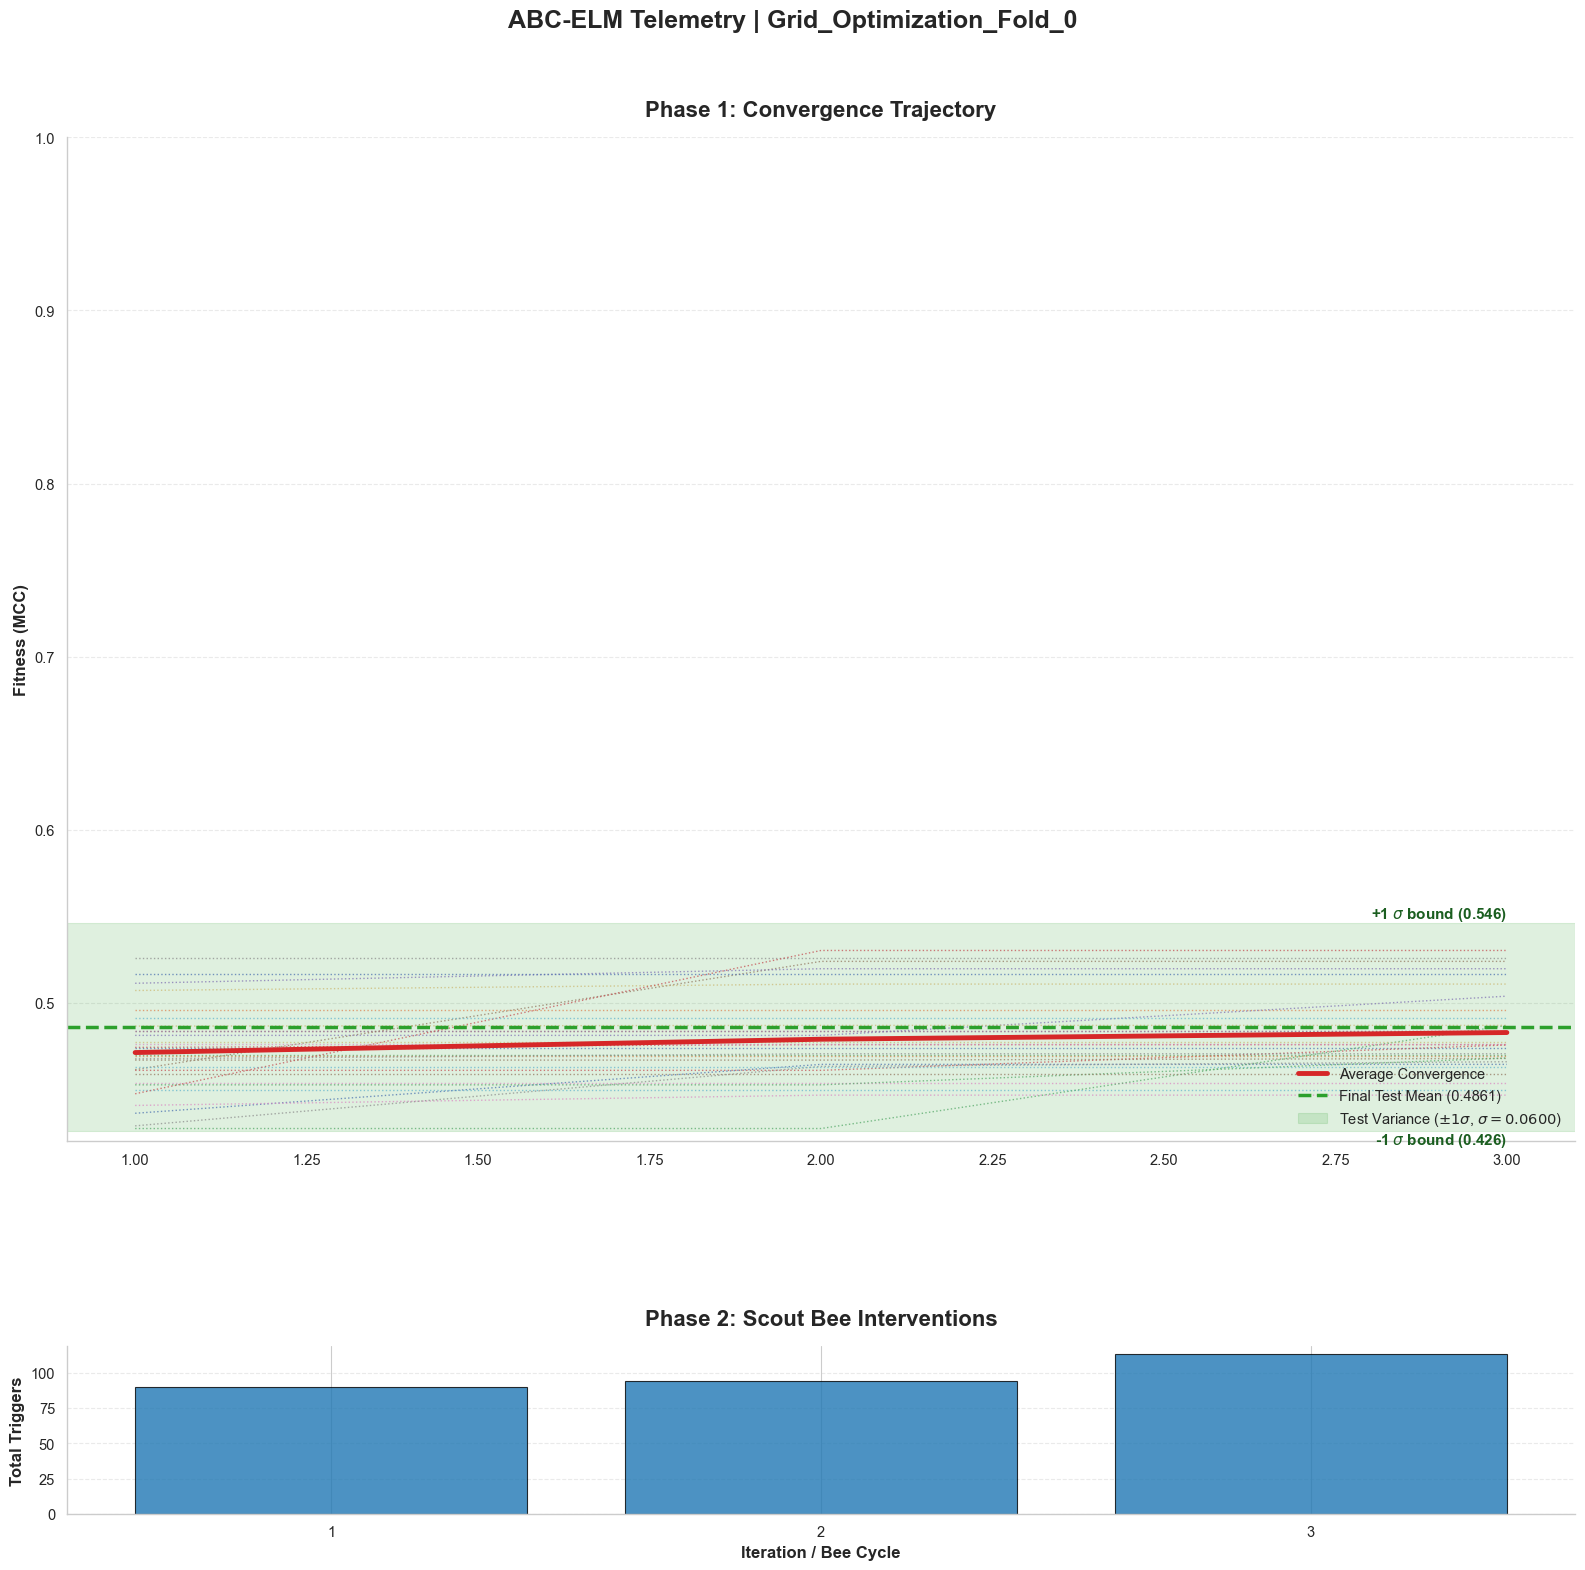

In [6]:
Plotting.plot_abc_dashboard(convergence_df,scout_df,mod,results_df=results_df,is_final_record=True)

In [7]:
GlobalSetting.save_dataframe_to_record(results_df, f"ABC_{mod}_Results.csv")
GlobalSetting.save_dataframe_to_record(convergence_df, f'ABC_{mod}_Convergence.csv')
GlobalSetting.save_dataframe_to_record(scout_df, f'ABC_{mod}_Scout_History.csv')

[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Optimization_Fold_0_Results.csv
[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Optimization_Fold_0_Convergence.csv
[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Optimization_Fold_0_Scout_History.csv
